# Linear Regression 2 - From Scratch, Object-Oriented

> **MLCourse · Machine Learning · 01_linear_regression**

We implement `MyLinearRegression` as a clean class with BOTH solvers from
notebook 01 - Gradient Descent and the Normal Equation - then verify it against
scikit-learn on REAL data. No synthetic data anywhere.

## What you'll learn
- Translating $\theta := \theta - \frac{\alpha}{m}X^T(X\theta-y)$ into production-style OOP code
- The sklearn-compatible API pattern: `fit` / `predict` / `score`
- Why feature scaling decides whether GD converges
- Proving our implementation matches the library on real data

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

def load(name):
    try:
        return sns.load_dataset(name)
    except Exception as e:
        print(f"offline? ({e})")
        return pd.DataFrame()

tips = load("tips")

## 1. Designing the class

Public API (mirrors sklearn so it is swappable):

| method | job |
|---|---|
| `fit(X, y)` | learn `intercept_` + `coef_` via chosen solver |
| `predict(X)` | return $X\theta$ |
| `score(X, y)` | return $R^2$ |

Attributes worth exposing: `coef_`, `intercept_`, `cost_history_`, `n_iter_`.

In [2]:
class MyLinearRegression:
    """
    Ordinary Least Squares linear regression, implemented two ways.

    Parameters
    ----------
    solver : {"gd", "normal"}
        "gd"     -> batch gradient descent (needs scaled features)
        "normal" -> closed form  θ = pinv(XᵀX) · Xᵀy   (pinv = safe inverse)
    lr : float
        Learning rate α for gradient descent.
    n_iters : int
        GD iterations.

    Attributes after fit()
    ----------------------
    intercept_ : float          θ₀
    coef_      : ndarray (n,)   θ₁..θₙ  (sklearn-compatible order)
    cost_history_ : list         J(θ) per iteration (GD only)
    n_iter_    : int            iterations actually run
    """

    def __init__(self, solver="normal", lr=0.1, n_iters=1000):
        if solver not in ("gd", "normal"):
            raise ValueError("solver must be 'gd' or 'normal'")
        self.solver = solver
        self.lr = lr
        self.n_iters = n_iters

    # ------------------------------------------------------------------ fit --
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).ravel()

        # Fold the bias into the matrix: first column of ones  =>  h(x) = Xb·w
        Xb = np.column_stack([np.ones(len(X)), X])

        if self.solver == "normal":
            # θ = (XᵀX)⁻¹Xᵀy ; pinv survives singular matrices gracefully
            w = np.linalg.pinv(Xb.T @ Xb) @ Xb.T @ y
            self.n_iter_ = 0
            self.cost_history_ = [self._mse(y, Xb @ w)]
        else:
            w, history = self._gradient_descent(Xb, y)
            self.cost_history_ = history
            self.n_iter_ = len(history)

        self.intercept_ = float(w[0])
        self.coef_ = w[1:].copy()
        return self                       # chaining-friendly like sklearn

    # -------------------------------------------------------- gradient step --
    def _gradient_descent(self, Xb, y):
        m = len(y)
        w = np.zeros(Xb.shape[1])
        history = []
        for _ in range(self.n_iters):
            grad = Xb.T @ (Xb @ w - y) / m      # ∇J = (1/m)·Xᵀ(Xθ−y)
            w -= self.lr * grad                  # θ := θ − α·∇J
            history.append(self._mse(y, Xb @ w))
        return w, history

    @staticmethod
    def _mse(y_true, y_pred):
        """J(θ) = (1/2m)‖y−ŷ‖² - the ½ cancels in the gradient anyway."""
        return float(((y_true - y_pred) ** 2).mean() / 2)

    # -------------------------------------------------------------- predict --
    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self.intercept_ + X @ self.coef_

    # ---------------------------------------------------------------- score --
    def score(self, X, y):
        """R² = 1 − SSE/SST."""
        y = np.asarray(y, dtype=float).ravel()
        ss_res = ((y - self.predict(X)) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        return float(1 - ss_res / ss_tot)

    def __repr__(self):
        return (f"MyLinearRegression(solver={self.solver!r}, "
                f"lr={self.lr}, n_iters={self.n_iters})")

print(repr(MyLinearRegression()))

MyLinearRegression(solver='normal', lr=0.1, n_iters=1000)


## 2. Sanity check on real data - simple regression (tips)

In [3]:
X = tips[["total_bill"]].values
y = tips["tip"].values

mine_normal = MyLinearRegression(solver="normal").fit(X, y)
sk_model = LinearRegression().fit(X, y)

print(f"{'':12s}{'intercept':>10s}{'slope':>8s}")
print(f"{'normal eq.':12s}{mine_normal.intercept_:>10.4f}{mine_normal.coef_[0]:>8.4f}")
print(f"{'sklearn':12s}{sk_model.intercept_:>10.4f}{sk_model.coef_[0]:>8.4f}")

assert abs(mine_normal.intercept_ - sk_model.intercept_) < 1e-6
assert abs(mine_normal.coef_[0] - sk_model.coef_[0]) < 1e-6
print("\n✓ identical to 6 decimals - the closed form is exactly what sklearn does")

             intercept   slope
normal eq.      0.9203  0.1050
sklearn         0.9203  0.1050

✓ identical to 6 decimals — the closed form is exactly what sklearn does


## 3. Gradient Descent needs SCALED features - prove it on real data

Diabetes features span wildly different ranges; watch raw vs standardized GD:

C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_61016\1259904178.py:66: RuntimeWarning: overflow encountered in square
  return float(((y_true - y_pred) ** 2).mean() / 2)
D:\projects\python\MLCourse\.venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_61016\1259904178.py:58: RuntimeWarning: overflow encountered in matmul
  grad = Xb.T @ (Xb @ w - y) / m      # ∇J = (1/m)·Xᵀ(Xθ−y)
C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_61016\1259904178.py:58: RuntimeWarning: invalid value encountered in matmul
  grad = Xb.T @ (Xb @ w - y) / m      # ∇J = (1/m)·Xᵀ(Xθ−y)
C:\Users\Thoyajaksha Kashyap\AppData\Local\Temp\ipykernel_61016\1259904178.py:59: RuntimeWarning: invalid value encountered in subtract
  w -= self.lr * grad                  # θ := θ − α·∇J


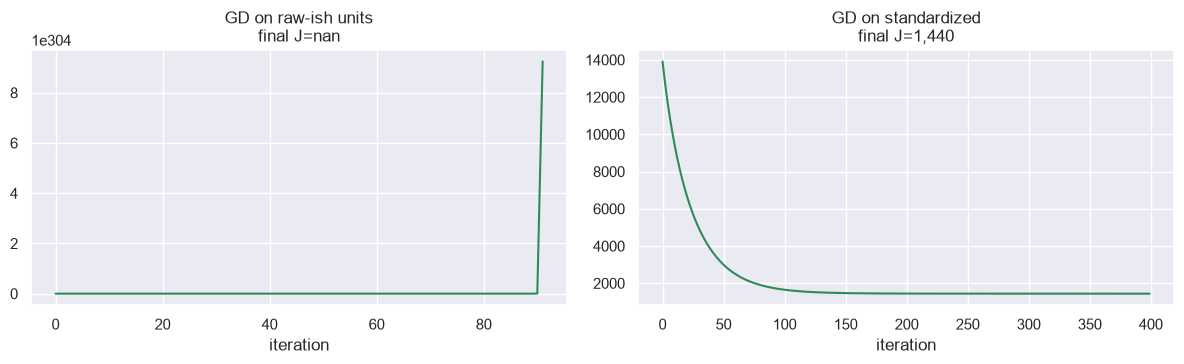

R² on FULL diabetes (GD, scaled): 0.5168


In [4]:
diab = load_diabetes(as_frame=True)
Xd_full, yd = diab.data, diab.target

scaler = StandardScaler().fit(Xd_full)
X_raw = Xd_full.values * np.array([1000, 100, 100, .1, .1, 100, .1, .01, .1, 10])
# ^ artificially widen scales to mimic 'unscaled real-world units'

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, Xv, title in [(axes[0], X_raw, "raw-ish units"),
                      (axes[1], scaler.transform(Xd_full), "standardized")]:
    m = MyLinearRegression(solver="gd", lr=0.02, n_iters=400).fit(Xv, yd.values)
    ax.plot(m.cost_history_, color="seagreen")
    ax.set_title(f"GD on {title}\nfinal J={m.cost_history_[-1]:,.0f}")
    ax.set_xlabel("iteration")
plt.tight_layout(); plt.show()

m_scaled = MyLinearRegression(solver="gd", lr=0.1, n_iters=800).fit(
    scaler.transform(Xd_full), yd.values)
print("R² on FULL diabetes (GD, scaled):",
      round(m_scaled.score(scaler.transform(Xd_full), yd.values), 4))

## 4. Multi-feature verification: all three solvers agree

In [5]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(
    scaler.transform(Xd_full), yd.values, test_size=.25, random_state=42)

results = {}
results["scratch/normal"] = MyLinearRegression("normal").fit(Xd_tr, yd_tr)
results["scratch/gd"]     = MyLinearRegression("gd", lr=.3, n_iters=5000).fit(Xd_tr, yd_tr)
results["sklearn"]        = LinearRegression().fit(Xd_tr, yd_tr)

rows = []
for name, mdl in results.items():
    pred = mdl.predict(Xd_te)
    r2 = r2_score(yd_te, pred)
    rows.append({"model": name,
                 "test R²": round(r2, 4),
                 "MAE": round(mean_absolute_error(yd_te, pred), 2),
                 "RMSE": round(float(np.sqrt(mean_squared_error(yd_te, pred))), 2)})
pd.DataFrame(rows)

,model,test R²,MAE,RMSE
0,scratch/normal,0.4849,41.55,53.37
1,scratch/gd,0.4849,41.55,53.37
2,sklearn,0.4849,41.55,53.37


In [6]:
# Coefficient agreement (GD should land on the same optimum given enough steps):
coefs = pd.DataFrame({
    "feature": Xd_full.columns,
    "normal": results["scratch/normal"].coef_,
    "gd": results["scratch/gd"].coef_,
    "sklearn": results["sklearn"].coef_,
}).round(3)
coefs

,feature,normal,gd,sklearn
0,age,2.271,2.271,2.271
1,sex,-11.510,-11.510,-11.510
2,bmi,25.303,25.303,25.303
3,bp,18.149,18.149,18.149
4,s1,-43.689,-43.689,-43.689
5,s2,24.175,24.175,24.175
6,s3,5.563,5.563,5.563
7,s4,12.818,12.818,12.818
8,s5,33.096,33.096,33.096
9,s6,1.252,1.252,1.252


> ⚠️ **Common pitfall:** comparing coefficients across DIFFERENT scalings is
meaningless - every model above consumed the SAME standardized matrix, so
numbers are directly comparable.

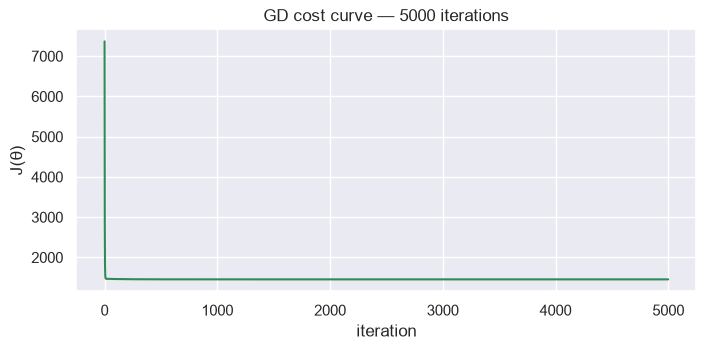

In [7]:
# Convergence quality of our GD run:
plt.figure(figsize=(8, 3.4))
plt.plot(results["scratch/gd"].cost_history_, color="seagreen")
plt.title(f"GD cost curve - {results['scratch/gd'].n_iter_} iterations")
plt.xlabel("iteration"); plt.ylabel("J(θ)")
plt.show()

## 5. Using the class end-to-end (mini walkthrough on tips, multi-feature)

In [8]:
tips_ml = pd.get_dummies(
    tips[["total_bill", "size", "smoker", "time"]],
    columns=["smoker", "time"], drop_first=True)

Xt, Xs, yt, ys = train_test_split(tips_ml.values.astype(float),
                                  tips["tip"].values,
                                  test_size=.25, random_state=7)

mine = MyLinearRegression("normal").fit(Xt, yt)
pred_mine = mine.predict(Xs)

out = pd.DataFrame({
    "actual": ys[:5].round(2),
    "predicted": pred_mine[:5].round(2),
})
print(out.to_string(index=False))
print(f"\ntest R² (scratch, tips): {mine.score(Xs, ys):.3f}")

coef_view = pd.Series(np.r_[mine.intercept_, mine.coef_],
                      index=["intercept"] + list(tips_ml.columns)).round(3)
print("\nlearned equation:")
print("tip =", " + ".join(f"{v}*{k}" for k, v in coef_view.items()))

 actual  predicted
   3.00       2.86
   2.18       3.35
   3.31       3.25
   3.00       4.84
   2.00       2.41

test R² (scratch, tips): 0.474

learned equation:
tip = 0.652*intercept + 0.093*total_bill + 0.199*size + -0.02*smoker_No + 0.018*time_Dinner


## Summary & key takeaways

- A tidy OOP wrapper turns two math formulas into a reusable estimator with the
  sklearn contract (`fit/predict/score`, trailing-underscore attributes).
- Normal Equation == sklearn's answer to machine precision; GD reaches the same
  optimum when given enough iterations and a sane learning rate.
- **Scale before GD** - mixed-magnitude features make one α wrong for everyone.
- Expose `cost_history_`: convergence plots are your first debugging tool.